In [1]:
import os
import re
import gc
import math
import json
import random
import warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoConfig,
    get_linear_schedule_with_warmup,
    DataCollatorWithPadding,
)
from torch.optim import AdamW

warnings.filterwarnings("ignore")

In [2]:
#config
class Config:
    seed: int = 42
    output_dir: str = "./outputs_transformer_project"
    max_length: int = 128
    batch_size: int = 4
    eval_batch_size: int = 4
    epochs: int = 2
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    early_stopping_patience: int = 2
    use_fp16: bool = True
    gradient_clip: float = 1.0

    # preprocessing
    remove_headers_footers_quotes: bool = True
    light_clean_text: bool = True
    remove_stopwords: bool = False
    use_stemming: bool = False
    handle_oov_words: bool = True
     # augmentation
    use_augmentation: bool = False
    augmentation_ratio: float = 0.15    # proportion of training samples to augment
    augmentation_method: str = "synonym"  # synonym or none

    # model experiments
    model_names: Tuple[str, ...] = (
        "distilbert-base-uncased",
        "bert-base-uncased",
        "roberta-base",
    )
    dropout_values: Tuple[float, ...] = (0.1, 0.3)
    head_types: Tuple[str, ...] = ("linear", "mlp", "attention_pooling")

    # runtime controls
    run_full_grid: bool = False
    best_model_for_interpretability: str = "distilbert-base-uncased"
    best_head_for_interpretability: str = "mlp"
    best_dropout_for_interpretability: float = 0.3


CFG = Config()

In [3]:
#utilities
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CFG.seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_FP16 = CFG.use_fp16 and torch.cuda.is_available()

os.makedirs(CFG.output_dir, exist_ok=True)


def save_json(data: Dict, path: str):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

In [4]:
#nltk resources
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer
NLTK_AVAILABLE = True
def setup_nltk():
    if not NLTK_AVAILABLE:
        print("NLTK not available. Skipping stopword/stemming/synonym tools.")
        return
    resources = ["stopwords", "wordnet", "omw-1.4"]
    for res in resources:
        try:
            nltk.download(res, quiet=True)
        except Exception:
            pass


setup_nltk()
STOPWORDS = set(stopwords.words("english")) if NLTK_AVAILABLE else set()
STEMMER = PorterStemmer() if NLTK_AVAILABLE else None

In [5]:
#data preprocessing
def basic_clean(text: str) -> str:
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def stronger_clean(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s.,!?'-]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def preprocess_text(
    text: str,
    light_clean_text: bool = True,
    remove_stopwords_flag: bool = False,
    use_stemming_flag: bool = False,
    handle_oov_words_flag: bool = True,
) -> str:
    if light_clean_text:
        text = basic_clean(text)
    else:
        text = stronger_clean(text)


    tokens = text.split()

    # For transformer models, aggressive stopword removal and stemming are usually not recommended
    if remove_stopwords_flag:
        tokens = [tok for tok in tokens if tok.lower() not in STOPWORDS]

    if use_stemming_flag and STEMMER is not None:
        tokens = [STEMMER.stem(tok) for tok in tokens]

    # OOV handling is mostly solved by subword tokenizers
    if handle_oov_words_flag:
        normalized = []
        for tok in tokens:
            tok = re.sub(r"(.)\1{3,}", r"\1\1", tok)
            normalized.append(tok)
        tokens = normalized

    return " ".join(tokens)

In [6]:
#data augmentation
def get_synonyms(word: str) -> List[str]:
    if not NLTK_AVAILABLE:
        return []
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            s = lemma.name().replace("_", " ").lower()
            if s != word.lower() and s.isalpha():
                synonyms.add(s)
    return list(synonyms)

In [7]:
def synonym_replacement(text: str, n_replacements: int = 2) -> str:
    words = text.split()
    if len(words) < 4:
        return text

    candidate_indices = [
        i for i, w in enumerate(words)
        if w.lower() not in STOPWORDS and w.isalpha()
    ]
    random.shuffle(candidate_indices)

    replaced = 0
    for idx in candidate_indices:
        syns = get_synonyms(words[idx])
        if syns:
            words[idx] = random.choice(syns)
            replaced += 1
        if replaced >= n_replacements:
            break
    return " ".join(words)

In [8]:
def augment_training_data(df_train: pd.DataFrame, ratio: float = 0.15, method: str = "synonym") -> pd.DataFrame:
    if not CFG.use_augmentation or method == "none":
        return df_train.copy()

    n_aug = int(len(df_train) * ratio)
    sampled = df_train.sample(n=n_aug, random_state=CFG.seed).copy()
    augmented_texts = []

    for txt in sampled["text"].tolist():
        if method == "synonym":
            augmented_texts.append(synonym_replacement(txt, n_replacements=2))
        else:
            augmented_texts.append(txt)

    sampled["text"] = augmented_texts
    augmented_df = pd.concat([df_train, sampled], axis=0).reset_index(drop=True)
    return augmented_df


In [9]:
#load dataset
def load_20newsgroups_dataframe() -> Tuple[pd.DataFrame, List[str]]:
    remove = ()
    if CFG.remove_headers_footers_quotes:
        remove = ("headers", "footers", "quotes")

    data = fetch_20newsgroups(subset="all", remove=remove)
    texts = data.data
    labels = data.target
    target_names = data.target_names

    processed_texts = [
        preprocess_text(
            txt,
            light_clean_text=CFG.light_clean_text,
            remove_stopwords_flag=CFG.remove_stopwords,
            use_stemming_flag=CFG.use_stemming,
            handle_oov_words_flag=CFG.handle_oov_words,
        )
        for txt in texts
    ]

    df = pd.DataFrame({
        "text": processed_texts,
        "label": labels,
        "label_name": [target_names[i] for i in labels],
    })

    df = df[df["text"].str.len() > 0].reset_index(drop=True)
    return df, target_names

In [10]:
#train/val/test split
def stratified_split(df: pd.DataFrame):
    train_df, test_df = train_test_split(
        df,
        test_size=0.15,
        stratify=df["label"],
        random_state=CFG.seed,
    )
    train_df, val_df = train_test_split(
        train_df,
        test_size=0.1765,  # makes final ~15% val and ~70% train
        stratify=train_df["label"],
        random_state=CFG.seed,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


In [11]:
#dataset class
class NewsDataset(Dataset):
    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_length: int = 256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding=False,
            return_tensors=None,
        )
        item = {k: torch.tensor(v, dtype=torch.long) for k, v in enc.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

In [12]:
#classfication head
class AttentionPooling(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, hidden_states: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        # hidden_states: [B, L, H]
        # attention_mask: [B, L]
        scores = self.attention(hidden_states).squeeze(-1)  # [B, L]
        scores = scores.masked_fill(attention_mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)
        pooled = torch.sum(hidden_states * weights.unsqueeze(-1), dim=1)
        return pooled


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_labels: int,
        dropout: float = 0.1,
        head_type: str = "linear",
        output_attentions: bool = False,
    ):
        super().__init__()
        self.model_name = model_name
        self.num_labels = num_labels
        self.head_type = head_type

        config = AutoConfig.from_pretrained(
            model_name,
            num_labels=num_labels,
            output_attentions=output_attentions,
        )

        # Never pass None into dropout config fields.
        if hasattr(config, "hidden_dropout_prob"):
            config.hidden_dropout_prob = dropout
        if hasattr(config, "attention_probs_dropout_prob"):
            config.attention_probs_dropout_prob = dropout
        if hasattr(config, "dropout"):
            config.dropout = dropout
        if hasattr(config, "attention_dropout"):
            config.attention_dropout = dropout

        if hasattr(config, "seq_classif_dropout"):
            config.seq_classif_dropout = dropout

        self.backbone = AutoModel.from_pretrained(model_name, config=config)
        hidden_size = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)

        if head_type == "linear":
            self.classifier = nn.Linear(hidden_size, num_labels)
        elif head_type == "mlp":
            self.classifier = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, num_labels),
            )
        elif head_type == "attention_pooling":
            self.attention_pool = AttentionPooling(hidden_size)
            self.classifier = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, num_labels),
            )
        else:
            raise ValueError(f"Unsupported head type: {head_type}")

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state

        if self.head_type == "attention_pooling":
            pooled = self.attention_pool(hidden_states, attention_mask)
        else:
            # CLS token for BERT/RoBERTa, first token fallback for DistilBERT
            pooled = hidden_states[:, 0]

        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {
            "loss": loss,
            "logits": logits,
            "attentions": outputs.attentions if hasattr(outputs, "attentions") else None,
        }

In [13]:
#training evaluation helpers
def move_batch_to_device(batch: Dict[str, torch.Tensor], device: torch.device) -> Dict[str, torch.Tensor]:
    return {k: v.to(device) for k, v in batch.items()}


def compute_metrics(y_true: List[int], y_pred: List[int]) -> Dict:
    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }


def train_one_epoch(model, loader, optimizer, scheduler, scaler):
    model.train()
    total_loss = 0.0
    preds_all, labels_all = [], []

    for batch in loader:
        batch = move_batch_to_device(batch, DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=USE_FP16):
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
            )
            loss = outputs["loss"]

        if USE_FP16:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.gradient_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.gradient_clip)
            optimizer.step()

        scheduler.step()

        total_loss += loss.item()
        logits = outputs["logits"].detach().cpu().numpy()
        preds = np.argmax(logits, axis=1)
        labels = batch["labels"].detach().cpu().numpy()
        preds_all.extend(preds.tolist())
        labels_all.extend(labels.tolist())

    metrics = compute_metrics(labels_all, preds_all)
    metrics["loss"] = total_loss / len(loader)
    return metrics


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    preds_all, labels_all = [], []
    attentions_cache = []

    for batch in loader:
        batch = move_batch_to_device(batch, DEVICE)
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        loss = outputs["loss"]
        total_loss += loss.item()

        logits = outputs["logits"].detach().cpu().numpy()
        preds = np.argmax(logits, axis=1)
        labels = batch["labels"].detach().cpu().numpy()
        preds_all.extend(preds.tolist())
        labels_all.extend(labels.tolist())

        if outputs["attentions"] is not None and len(attentions_cache) < 2:
            attentions_cache.append(outputs["attentions"])

    metrics = compute_metrics(labels_all, preds_all)
    metrics["loss"] = total_loss / len(loader)
    return metrics, labels_all, preds_all, attentions_cache


class EarlyStopping:
    def __init__(self, patience: int = 2, mode: str = "max"):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, value: float):
        if self.best_score is None:
            self.best_score = value
            return True

        improved = value > self.best_score if self.mode == "max" else value < self.best_score
        if improved:
            self.best_score = value
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False

In [14]:
#dataloaders
def make_dataloaders(train_df, val_df, test_df, tokenizer):
    train_ds = NewsDataset(train_df["text"].tolist(), train_df["label"].tolist(), tokenizer, CFG.max_length)
    val_ds = NewsDataset(val_df["text"].tolist(), val_df["label"].tolist(), tokenizer, CFG.max_length)
    test_ds = NewsDataset(test_df["text"].tolist(), test_df["label"].tolist(), tokenizer, CFG.max_length)

    collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, collate_fn=collator)
    val_loader = DataLoader(val_ds, batch_size=CFG.eval_batch_size, shuffle=False, collate_fn=collator)
    test_loader = DataLoader(test_ds, batch_size=CFG.eval_batch_size, shuffle=False, collate_fn=collator)
    return train_loader, val_loader, test_loader

In [15]:
#main training
def run_experiment(
    model_name: str,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    target_names: List[str],
    dropout: float = 0.1,
    head_type: str = "linear",
):
    print("\n" + "=" * 90)
    print(f"Running model={model_name} | dropout={dropout} | head={head_type}")
    print("=" * 90)

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    train_loader, val_loader, test_loader = make_dataloaders(train_df, val_df, test_df, tokenizer)

    model = TransformerClassifier(
        model_name=model_name,
        num_labels=len(target_names),
        dropout=dropout,
        head_type=head_type,
        output_attentions=False,
    ).to(DEVICE)

    total_steps = len(train_loader) * CFG.epochs
    warmup_steps = int(total_steps * CFG.warmup_ratio)

    optimizer = AdamW(model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_FP16)
    early_stopper = EarlyStopping(patience=CFG.early_stopping_patience, mode="max")

    exp_name = f"{model_name.replace('/', '_')}__drop{dropout}__{head_type}__sw{CFG.remove_stopwords}__stem{CFG.use_stemming}__aug{CFG.use_augmentation}"
    exp_dir = os.path.join(CFG.output_dir, exp_name)
    os.makedirs(exp_dir, exist_ok=True)

    history = []
    best_ckpt_path = os.path.join(exp_dir, "best_model.pt")

    for epoch in range(1, CFG.epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, scheduler, scaler)
        val_metrics, _, _, _ = evaluate(model, val_loader)

        row = {
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)

        print(
            f"Epoch {epoch}/{CFG.epochs} | "
            f"Train Loss={train_metrics['loss']:.4f} | Train F1={train_metrics['f1_macro']:.4f} | "
            f"Val Loss={val_metrics['loss']:.4f} | Val F1={val_metrics['f1_macro']:.4f}"
        )

        improved = early_stopper.step(val_metrics["f1_macro"])
        if improved:
            torch.save(model.state_dict(), best_ckpt_path)
            save_json(row, os.path.join(exp_dir, "best_val_metrics.json"))

        # save checkpoint each epoch
        torch.save(model.state_dict(), os.path.join(exp_dir, f"checkpoint_epoch_{epoch}.pt"))

        if early_stopper.should_stop:
            print("Early stopping triggered.")
            break

    # load best model
    model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))

    val_metrics, val_true, val_pred, val_attn = evaluate(model, val_loader)
    test_metrics, test_true, test_pred, test_attn = evaluate(model, test_loader)

    # reports
    cls_report = classification_report(test_true, test_pred, target_names=target_names, zero_division=0, output_dict=True)
    report_df = pd.DataFrame(cls_report).transpose()
    report_df.to_csv(os.path.join(exp_dir, "classification_report_test.csv"), index=True)

    # confusion matrix
    cm = confusion_matrix(test_true, test_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names
    )
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # training history plot
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(os.path.join(exp_dir, "training_history.csv"), index=False)

    plt.figure(figsize=(10, 5))
    plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss")
    plt.plot(hist_df["epoch"], hist_df["val_loss"], label="Val Loss")
    plt.legend()
    plt.title(f"Loss Curves - {exp_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.savefig(os.path.join(exp_dir, "loss_curves.png"), dpi=200)
    plt.close()

    plt.figure(figsize=(10, 5))
    plt.plot(hist_df["epoch"], hist_df["train_f1_macro"], label="Train Macro-F1")
    plt.plot(hist_df["epoch"], hist_df["val_f1_macro"], label="Val Macro-F1")
    plt.legend()
    plt.title(f"Macro-F1 Curves - {exp_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.tight_layout()
    plt.savefig(os.path.join(exp_dir, "f1_curves.png"), dpi=200)
    plt.close()

    summary = {
        "experiment_name": exp_name,
        "model_name": model_name,
        "dropout": dropout,
        "head_type": head_type,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "output_dir": exp_dir,
    }
    save_json(summary, os.path.join(exp_dir, "summary.json"))

    # cleanup
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return summary, test_true, test_pred, test_attn

In [16]:
#attention analysis
@torch.no_grad()
def inspect_attention_for_text(model_name: str, checkpoint_path: str, text: str, target_names: List[str], dropout: float, head_type: str):
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = TransformerClassifier(
        model_name=model_name,
        num_labels=len(target_names),
        dropout=dropout,
        head_type=head_type,
        output_attentions=True,
    ).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()

    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=CFG.max_length)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    outputs = model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])

    probs = torch.softmax(outputs["logits"], dim=-1).squeeze(0).detach().cpu().numpy()
    pred_idx = int(np.argmax(probs))
    pred_label = target_names[pred_idx]

    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"].squeeze(0).tolist())
    attentions = outputs["attentions"]

    if attentions is not None:
        last_layer = attentions[-1][0]             # [heads, seq, seq]
        avg_heads = last_layer.mean(dim=0)         # [seq, seq]
        cls_attention = avg_heads[0].detach().cpu().numpy()
    else:
        cls_attention = np.zeros(len(tokens))

    attn_df = pd.DataFrame({
        "token": tokens,
        "attention_from_cls": cls_attention[:len(tokens)],
    }).sort_values("attention_from_cls", ascending=False)

    return {
        "predicted_label": pred_label,
        "predicted_index": pred_idx,
        "top_prob": float(probs[pred_idx]),
        "top_tokens": attn_df.head(20),
    }

In [17]:
#misclassfication
def save_misclassified_examples(test_df: pd.DataFrame, y_true: List[int], y_pred: List[int], target_names: List[str], save_path: str, n: int = 50):
    rows = []
    for i, (t, p) in enumerate(zip(y_true, y_pred)):
        if t != p:
            rows.append({
                "text": test_df.iloc[i]["text"],
                "true_label": target_names[t],
                "pred_label": target_names[p],
            })
    mis_df = pd.DataFrame(rows)
    mis_df.head(n).to_csv(save_path, index=False)
    return mis_df

In [18]:
#lime explainability
def build_predict_proba_function(model_name: str, checkpoint_path: str, num_labels: int, dropout: float, head_type: str):
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = TransformerClassifier(
        model_name=model_name,
        num_labels=num_labels,
        dropout=dropout,
        head_type=head_type,
        output_attentions=False,
    ).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()

    def predict_proba(texts: List[str]) -> np.ndarray:
        probs_all = []
        for i in range(0, len(texts), CFG.eval_batch_size):
            batch_texts = texts[i:i + CFG.eval_batch_size]
            enc = tokenizer(
                batch_texts,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=CFG.max_length,
            )
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            with torch.no_grad():
                outputs = model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
                probs = torch.softmax(outputs["logits"], dim=-1).detach().cpu().numpy()
            probs_all.append(probs)
        return np.vstack(probs_all)

    return predict_proba

def run_lime_explanation(text: str, target_names: List[str], predict_proba_fn, save_html_path: str):
    if not LIME_AVAILABLE:
        print("LIME is not installed. Run: pip install lime")
        return None

    explainer = LimeTextExplainer(class_names=target_names)
    explanation = explainer.explain_instance(
        text_instance=text,
        classifier_fn=predict_proba_fn,
        num_features=12,
        num_samples=200,
    )
    explanation.save_to_file(save_html_path)
    return explanation

In [19]:
#onnx export
def export_to_onnx(model_name: str, checkpoint_path: str, num_labels: int, dropout: float, head_type: str, save_path: str):
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = TransformerClassifier(
        model_name=model_name,
        num_labels=num_labels,
        dropout=dropout,
        head_type=head_type,
        output_attentions=False,
    ).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()

    sample = tokenizer(
        "This is a sample text for ONNX export.",
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=32,
    )
    input_ids = sample["input_ids"].to(DEVICE)
    attention_mask = sample["attention_mask"].to(DEVICE)

    class Wrapper(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, input_ids, attention_mask):
            return self.model(input_ids=input_ids, attention_mask=attention_mask)["logits"]

    wrapper = Wrapper(model).to(DEVICE)

    torch.onnx.export(
        wrapper,
        (input_ids, attention_mask),
        save_path,
        input_names=["input_ids", "attention_mask"],
        output_names=["logits"],
        dynamic_axes={
            "input_ids": {0: "batch_size", 1: "sequence_length"},
            "attention_mask": {0: "batch_size", 1: "sequence_length"},
            "logits": {0: "batch_size"},
        },
        opset_version=14,
    )
    print(f"ONNX model saved to {save_path}")

Using device: cuda
Loading dataset...
                                                text  label  \
0  I am sure some bashers of Pens fans are pretty...     10   
1  My brother is in the market for a high-perform...      3   
2  Finally you said what you dream about. Mediter...     17   
3  Think! It's the SCSI card doing the DMA transf...      3   
4  1) I have an old Jasmine drive which I cannot ...      4   

                 label_name  
0          rec.sport.hockey  
1  comp.sys.ibm.pc.hardware  
2     talk.politics.mideast  
3  comp.sys.ibm.pc.hardware  
4     comp.sys.mac.hardware  
Total samples: 18331
Number of classes: 20
Train: 12830 | Val: 2751 | Test: 2750
Train after augmentation: 12830

Running model=distilbert-base-uncased | dropout=0.1 | head=linear


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Attention analysis example:
misc.forsale 0.6689188480377197
       token  attention_from_cls
0      [CLS]            0.164249
3    posting            0.091878
26       dan            0.062386
16  computer            0.055269
36     [SEP]            0.053345
4       this            0.049241
8     friend            0.045853
9         of            0.035700
34      1804            0.035142
18         ,            0.033298
LIME not installed. Skipping LIME explanation.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ONNX export skipped due to error: No module named 'onnxscript'

All done.
Artifacts saved to: ./outputs_transformer_project


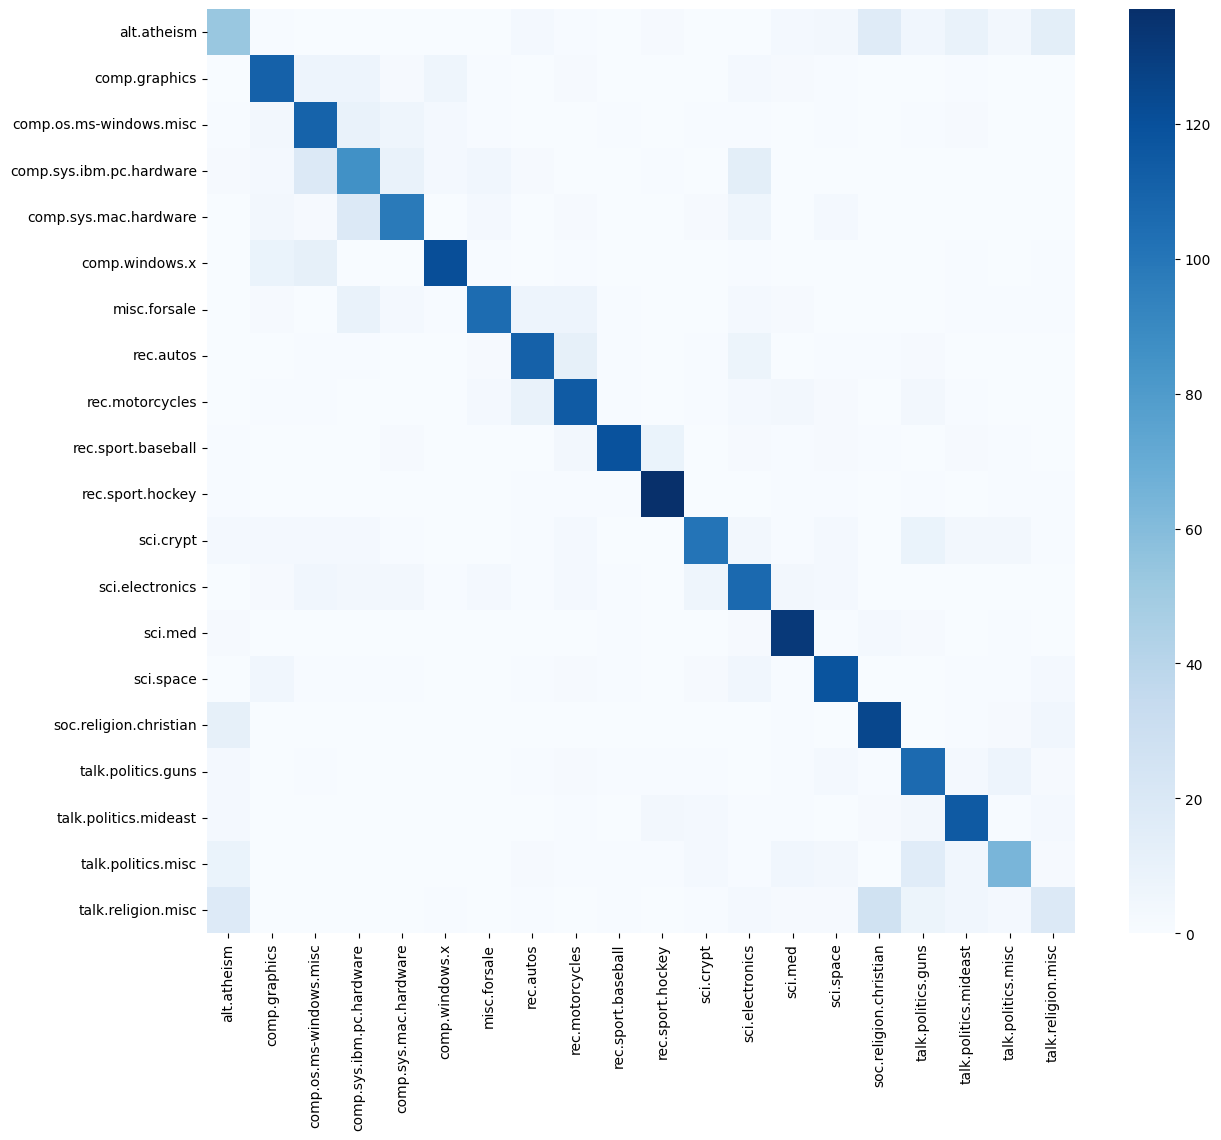

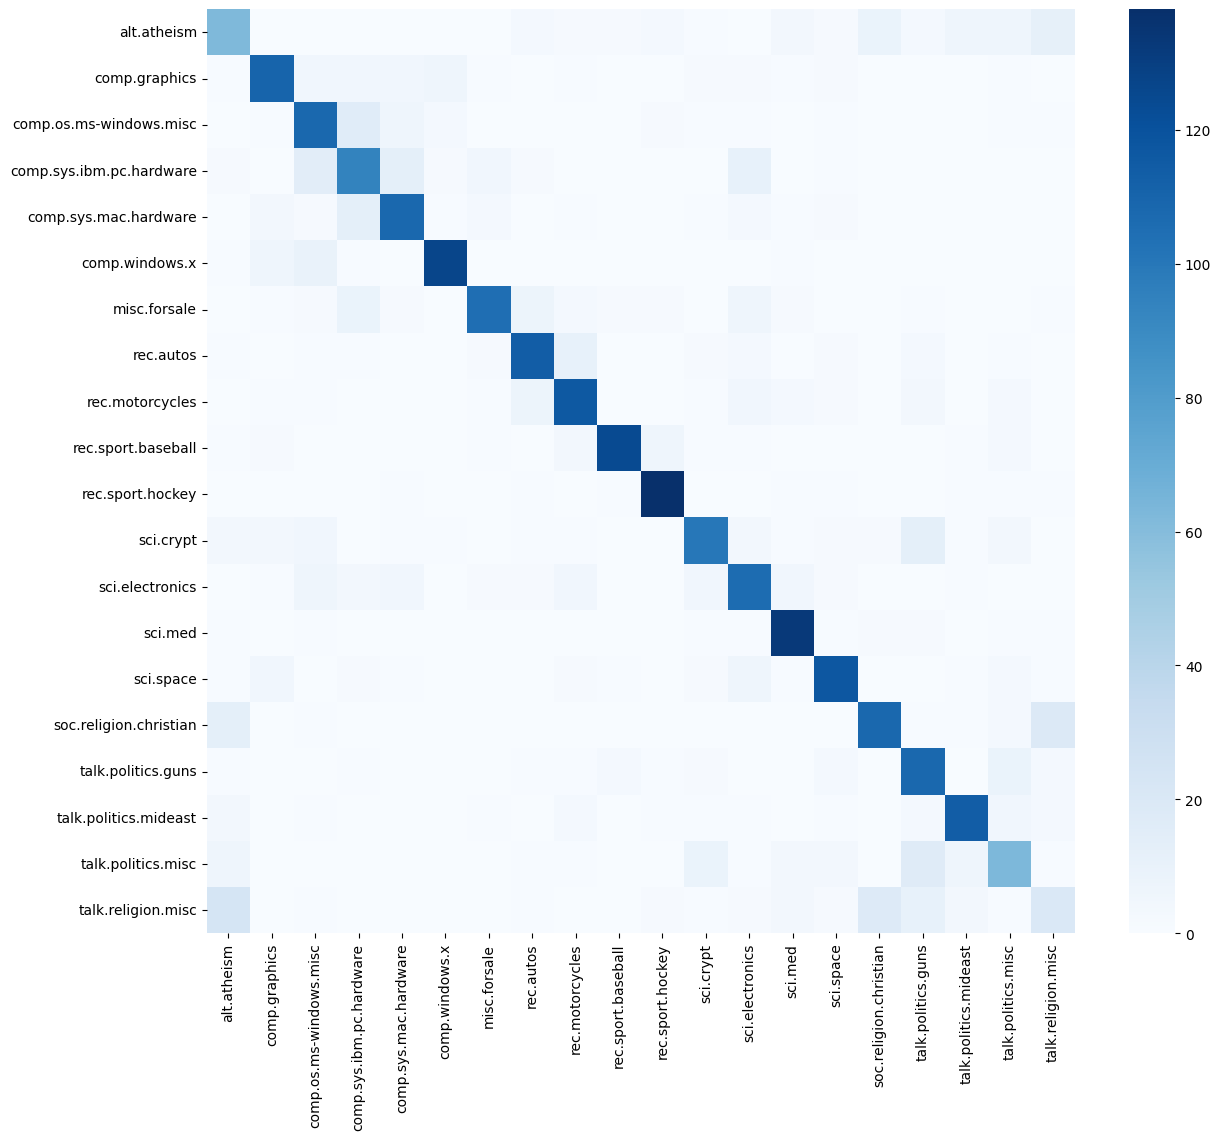

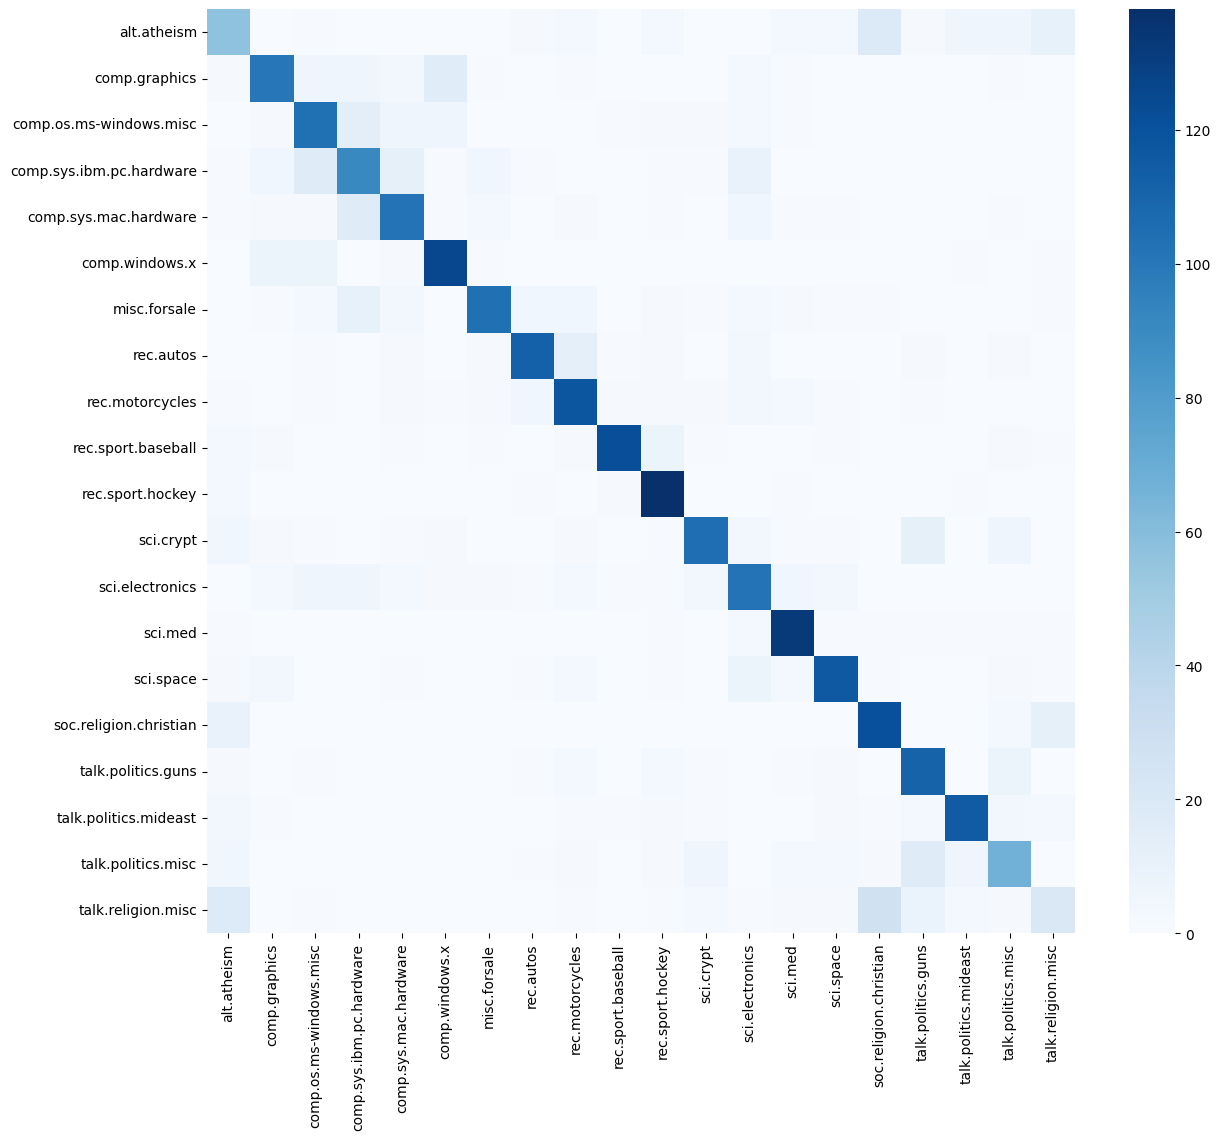

In [20]:
#main script
def main():
    print(f"Using device: {DEVICE}")
    print("Loading dataset...")
    df, target_names = load_20newsgroups_dataframe()
    print(df.head())
    print(f"Total samples: {len(df)}")
    print(f"Number of classes: {len(target_names)}")

    train_df, val_df, test_df = stratified_split(df)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    train_df_aug = augment_training_data(
        train_df,
        ratio=CFG.augmentation_ratio,
        method=CFG.augmentation_method,
    )
    print(f"Train after augmentation: {len(train_df_aug)}")

    all_results = []
    best_summary = None
    best_score = -1

    if CFG.run_full_grid:
        experiments = [
            (m, d, h)
            for m in CFG.model_names
            for d in CFG.dropout_values
            for h in CFG.head_types
        ]
    else:
        experiments = [
            ("distilbert-base-uncased", 0.1, "linear"),
            ("bert-base-uncased", 0.1, "linear"),
            ("roberta-base", 0.1, "linear"),]

    for model_name, dropout, head_type in experiments:
        summary, test_true, test_pred, _ = run_experiment(
            model_name=model_name,
            train_df=train_df_aug,
            val_df=val_df,
            test_df=test_df,
            target_names=target_names,
            dropout=dropout,
            head_type=head_type,
        )
        all_results.append(summary)

        if summary["test_metrics"]["f1_macro"] > best_score:
            best_score = summary["test_metrics"]["f1_macro"]
            best_summary = summary

    results_table = []
    for x in all_results:
        row = {
            "experiment_name": x["experiment_name"],
            "model_name": x["model_name"],
            "dropout": x["dropout"],
            "head_type": x["head_type"],
            **x["test_metrics"],
        }
        results_table.append(row)

    results_df = pd.DataFrame(results_table).sort_values("f1_macro", ascending=False)
    results_df.to_csv(os.path.join(CFG.output_dir, "all_experiment_results.csv"), index=False)
    print("\nFinal results:")
    print(results_df)

    if best_summary is None:
        raise RuntimeError("No experiments completed successfully.")

    print("\nBest experiment:")
    print(best_summary)

    best_exp_dir = best_summary["output_dir"]
    best_ckpt_path = os.path.join(best_exp_dir, "best_model.pt")

    # Save misclassified examples for best model
    pred_file = os.path.join(best_exp_dir, "test_predictions.csv")
    tokenizer = AutoTokenizer.from_pretrained(best_summary["model_name"], use_fast=True)
    _, _, test_loader = make_dataloaders(train_df_aug, val_df, test_df, tokenizer)

    best_model = TransformerClassifier(
        model_name=best_summary["model_name"],
        num_labels=len(target_names),
        dropout=best_summary["dropout"],
        head_type=best_summary["head_type"],
        output_attentions=True,
    ).to(DEVICE)
    best_model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))

    _, test_true, test_pred, _ = evaluate(best_model, test_loader)
    pred_df = test_df.copy()
    pred_df["true_label_name"] = [target_names[x] for x in test_true]
    pred_df["pred_label"] = test_pred
    pred_df["pred_label_name"] = [target_names[x] for x in test_pred]
    pred_df.to_csv(pred_file, index=False)

    mis_df = save_misclassified_examples(
        test_df=test_df,
        y_true=test_true,
        y_pred=test_pred,
        target_names=target_names,
        save_path=os.path.join(best_exp_dir, "misclassified_examples.csv"),
        n=100,
    )
    print(f"Misclassified examples saved. Count: {len(mis_df)}")

    # Attention analysis
    sample_text = test_df.iloc[0]["text"]
    attn_info = inspect_attention_for_text(
        model_name=best_summary["model_name"],
        checkpoint_path=best_ckpt_path,
        text=sample_text,
        target_names=target_names,
        dropout=best_summary["dropout"],
        head_type=best_summary["head_type"],
    )
    attn_info["top_tokens"].to_csv(os.path.join(best_exp_dir, "attention_top_tokens.csv"), index=False)
    print("\nAttention analysis example:")
    print(attn_info["predicted_label"], attn_info["top_prob"])
    print(attn_info["top_tokens"].head(10))

    # LIME explanation for one sample
    try:
      from lime.lime_text import LimeTextExplainer
      LIME_AVAILABLE = True
    except ImportError:
      LIME_AVAILABLE = False
    if LIME_AVAILABLE:
        predict_proba_fn = build_predict_proba_function(
            model_name=best_summary["model_name"],
            checkpoint_path=best_ckpt_path,
            num_labels=len(target_names),
            dropout=best_summary["dropout"],
            head_type=best_summary["head_type"],
        )
        lime_text = test_df.iloc[1]["text"]
        run_lime_explanation(
            text=lime_text,
            target_names=target_names,
            predict_proba_fn=predict_proba_fn,
            save_html_path=os.path.join(best_exp_dir, "lime_explanation.html"),
        )
        print("LIME explanation saved.")
    else:
        print("LIME not installed. Skipping LIME explanation.")

    # ONNX export
    try:
        export_to_onnx(
            model_name=best_summary["model_name"],
            checkpoint_path=best_ckpt_path,
            num_labels=len(target_names),
            dropout=best_summary["dropout"],
            head_type=best_summary["head_type"],
            save_path=os.path.join(best_exp_dir, "best_model.onnx"),
        )
    except Exception as e:
        print(f"ONNX export skipped due to error: {e}")

    print("\nAll done.")
    print(f"Artifacts saved to: {CFG.output_dir}")


if __name__ == "__main__":
    main()

Using device: cuda
Loading dataset...
                                                text  label  \
0  I am sure some bashers of Pens fans are pretty...     10   
1  My brother is in the market for a high-perform...      3   
2  Finally you said what you dream about. Mediter...     17   
3  Think! It's the SCSI card doing the DMA transf...      3   
4  1) I have an old Jasmine drive which I cannot ...      4   

                 label_name  
0          rec.sport.hockey  
1  comp.sys.ibm.pc.hardware  
2     talk.politics.mideast  
3  comp.sys.ibm.pc.hardware  
4     comp.sys.mac.hardware  
Total samples: 18331
Number of classes: 20
Train: 12830 | Val: 2751 | Test: 2750
Train after augmentation: 12830

Running model=distilbert-base-uncased | dropout=0.1 | head=linear


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/2 | Train Loss=1.3013 | Train F1=0.5891 | Val Loss=0.9523 | Val F1=0.6924
Epoch 2/2 | Train Loss=0.6593 | Train F1=0.7890 | Val Loss=0.9638 | Val F1=0.7282

Running model=bert-base-uncased | dropout=0.1 | head=linear


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Attention analysis example:
misc.forsale 0.8164381980895996
      token  attention_from_cls
36    [SEP]            0.097639
35        .            0.078965
24   please            0.076427
26      dan            0.063902
0     [CLS]            0.061634
4      this            0.058968
3   posting            0.044231
2        am            0.044165
1         i            0.040328
5   message            0.038009
LIME not installed. Skipping LIME explanation.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ONNX export skipped due to error: No module named 'onnxscript'

All done.
Artifacts saved to: ./outputs_transformer_project


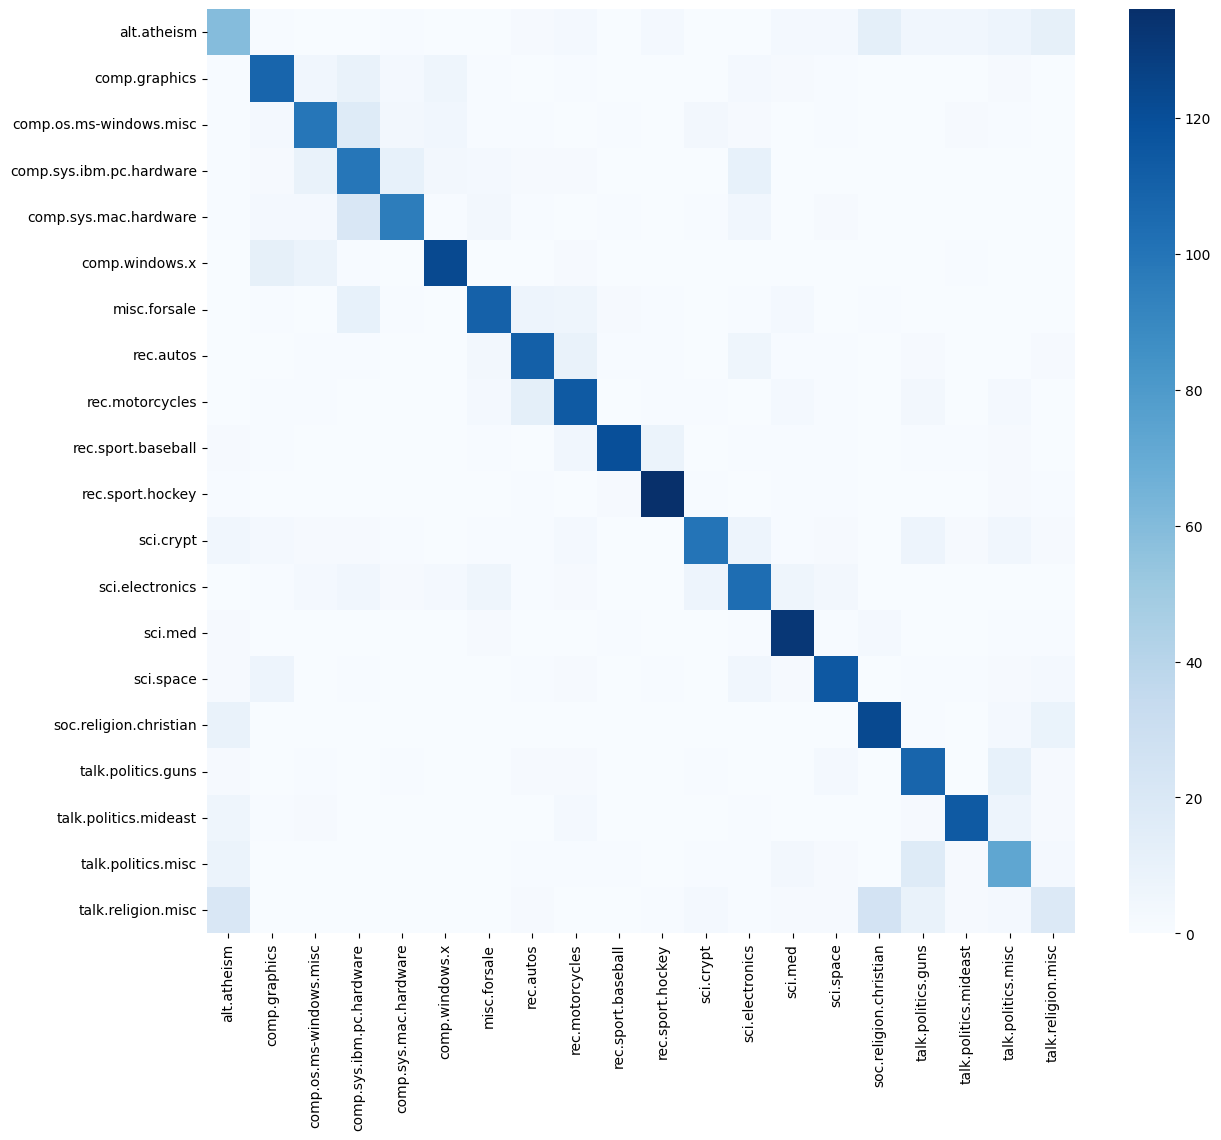

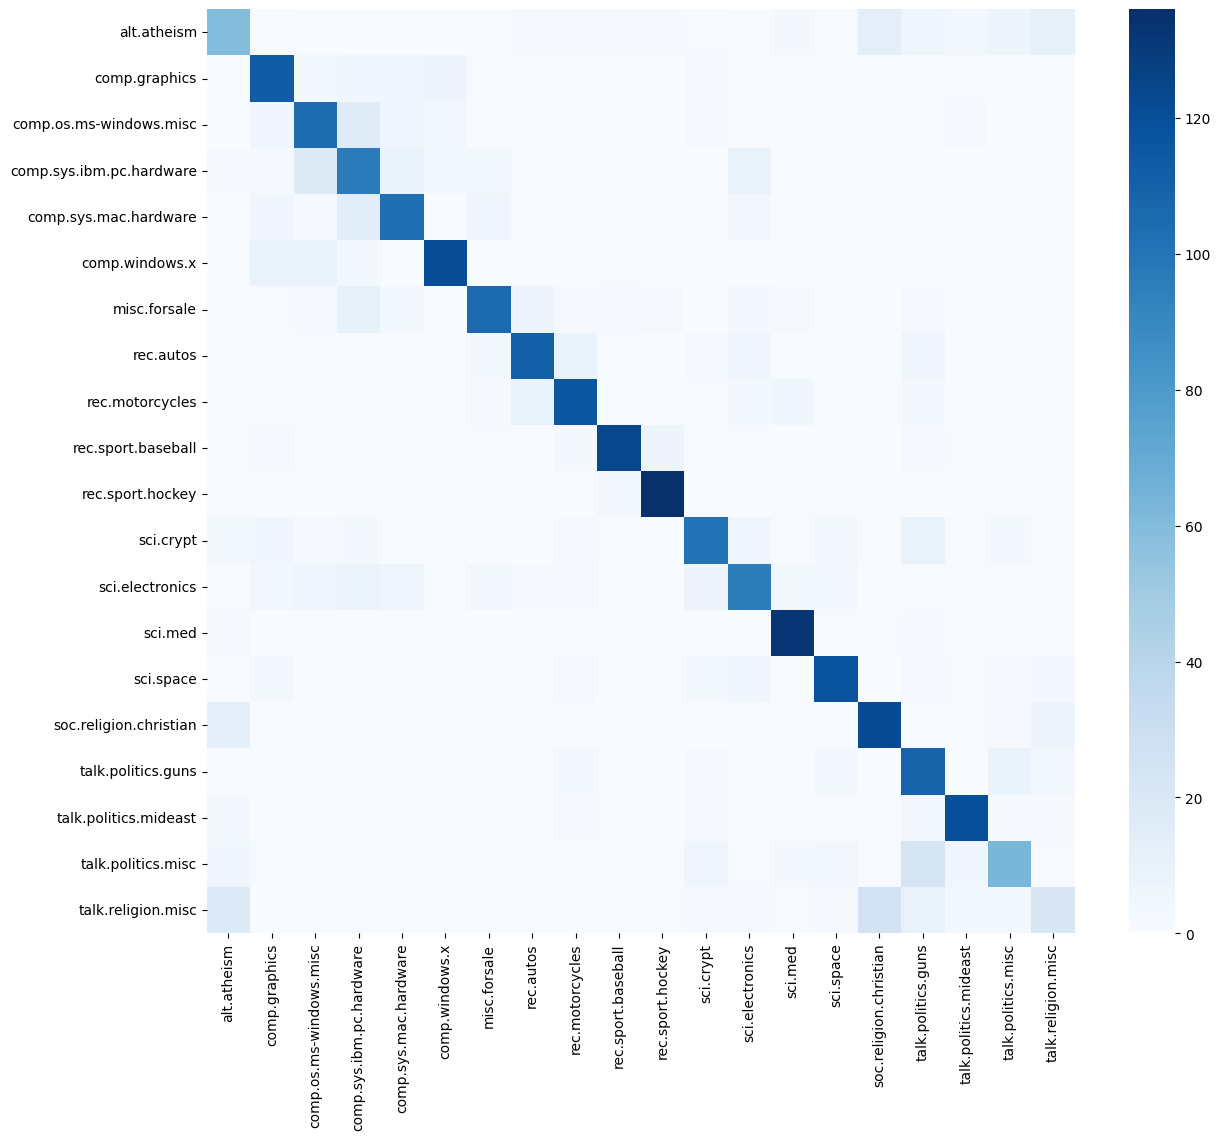

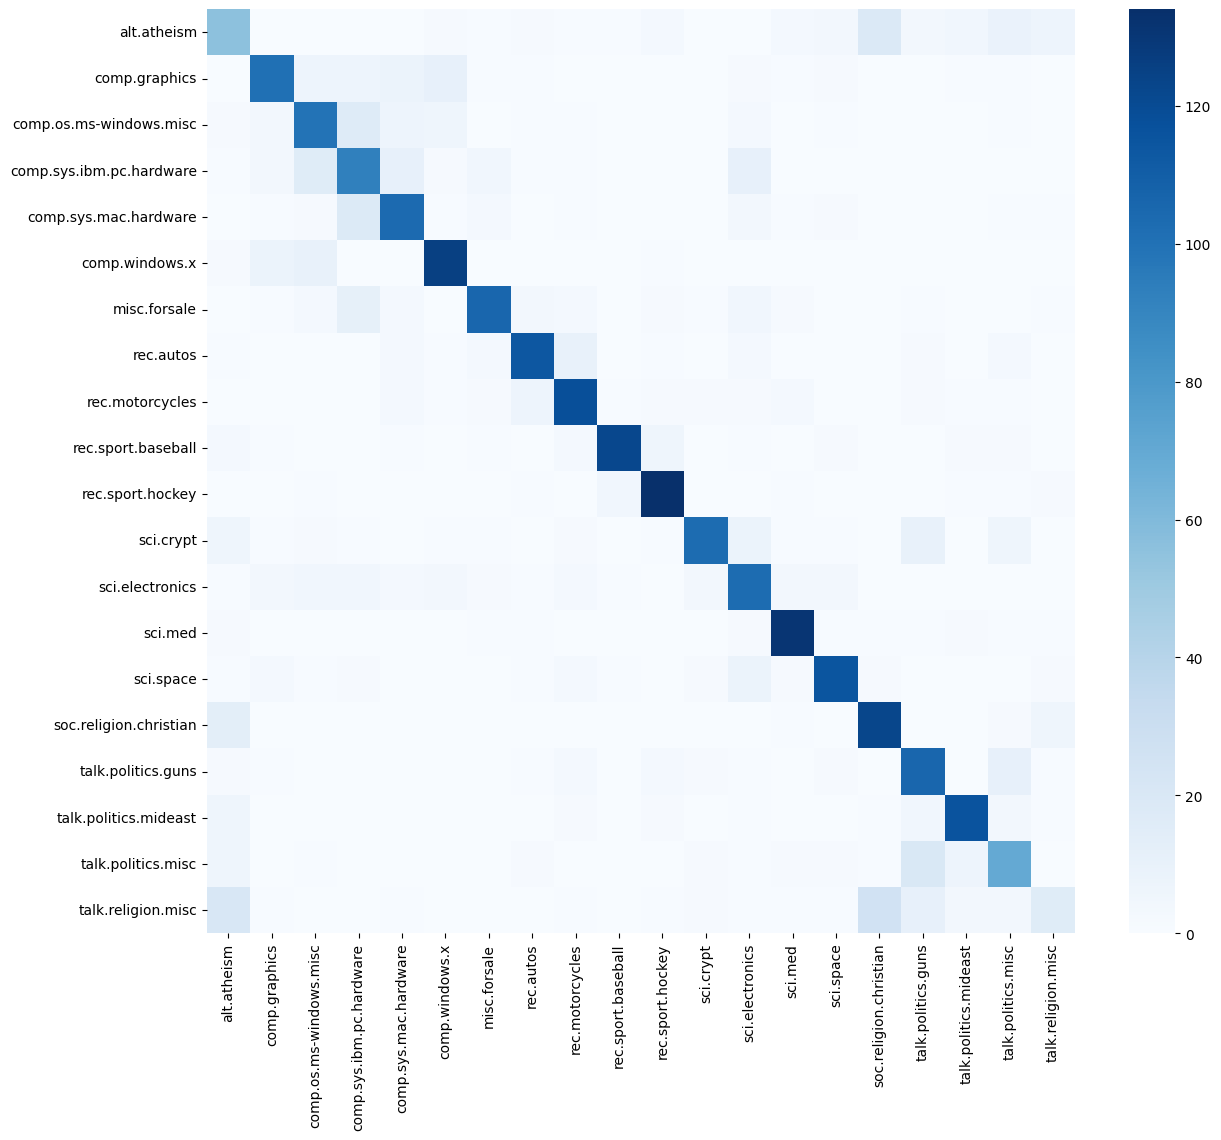

In [21]:
CFG.remove_stopwords = False
CFG.use_stemming = False
CFG.use_augmentation = False

main()

Using device: cuda
Loading dataset...
                                                text  label  \
0  I am sure some bashers of Pens fans are pretty...     10   
1  My brother is in the market for a high-perform...      3   
2  Finally you said what you dream about. Mediter...     17   
3  Think! It's the SCSI card doing the DMA transf...      3   
4  1) I have an old Jasmine drive which I cannot ...      4   

                 label_name  
0          rec.sport.hockey  
1  comp.sys.ibm.pc.hardware  
2     talk.politics.mideast  
3  comp.sys.ibm.pc.hardware  
4     comp.sys.mac.hardware  
Total samples: 18331
Number of classes: 20
Train: 12830 | Val: 2751 | Test: 2750
Train after augmentation: 12830

Running model=distilbert-base-uncased | dropout=0.1 | head=linear


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/2 | Train Loss=1.2821 | Train F1=0.5954 | Val Loss=0.9536 | Val F1=0.6935
Epoch 2/2 | Train Loss=0.6616 | Train F1=0.7929 | Val Loss=0.9641 | Val F1=0.7248

Running model=bert-base-uncased | dropout=0.1 | head=linear


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Attention analysis example:
comp.sys.mac.hardware 0.9909653663635254
        token  attention_from_cls
28         hd            0.108570
29        mac            0.085313
74         hd            0.080690
122        un            0.024455
125  delaware            0.018235
0       [CLS]            0.017782
59      check            0.016547
13      ##ter            0.016392
71         ar            0.015719
35          r            0.015440
LIME not installed. Skipping LIME explanation.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ONNX export skipped due to error: No module named 'onnxscript'

All done.
Artifacts saved to: ./outputs_transformer_project


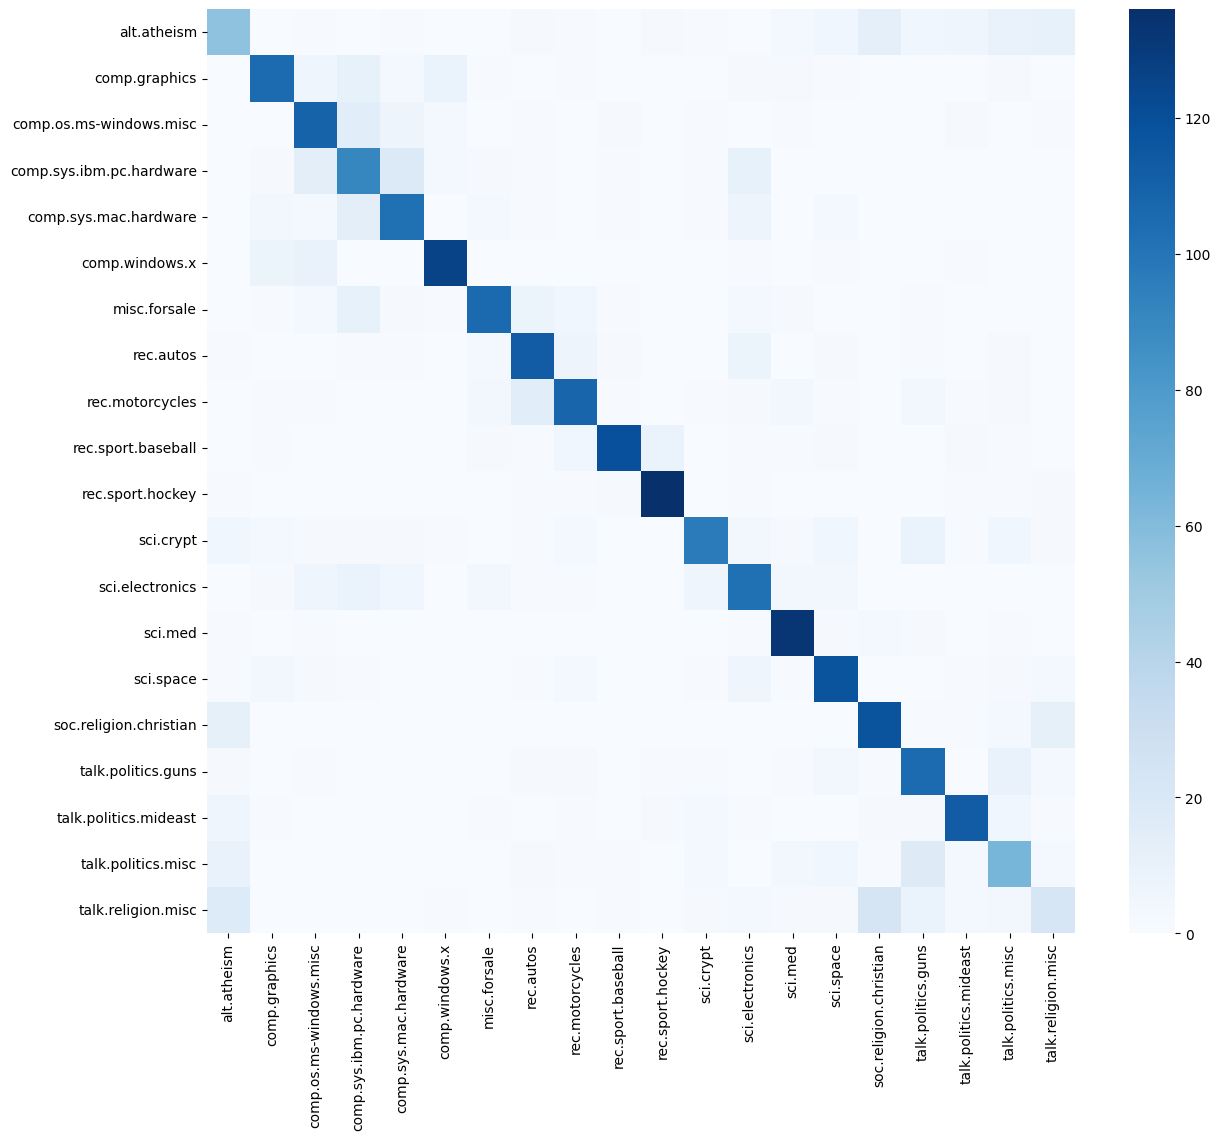

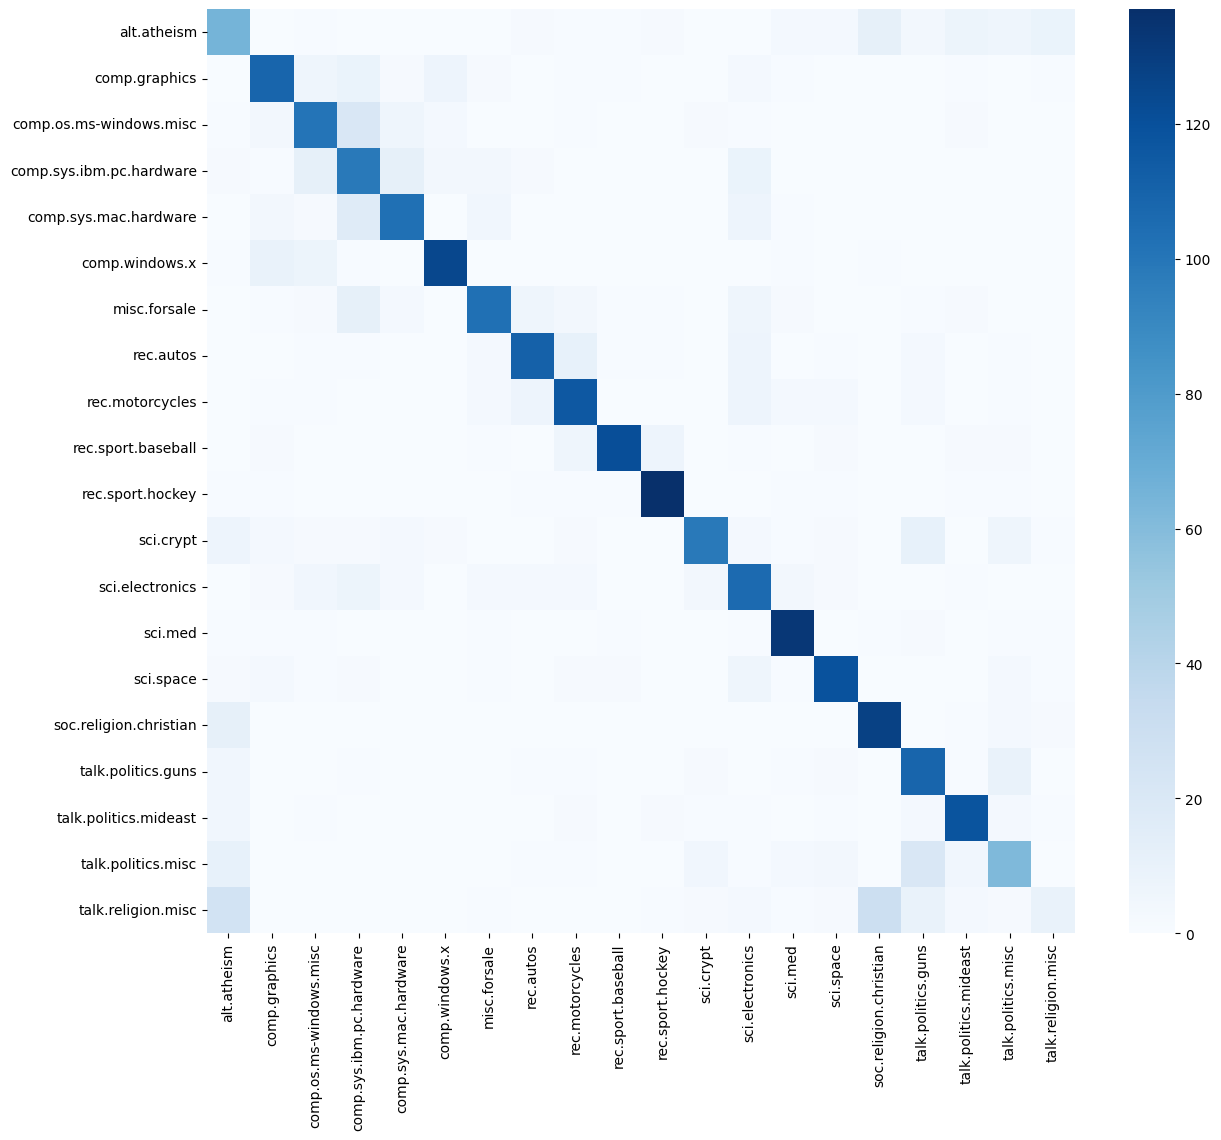

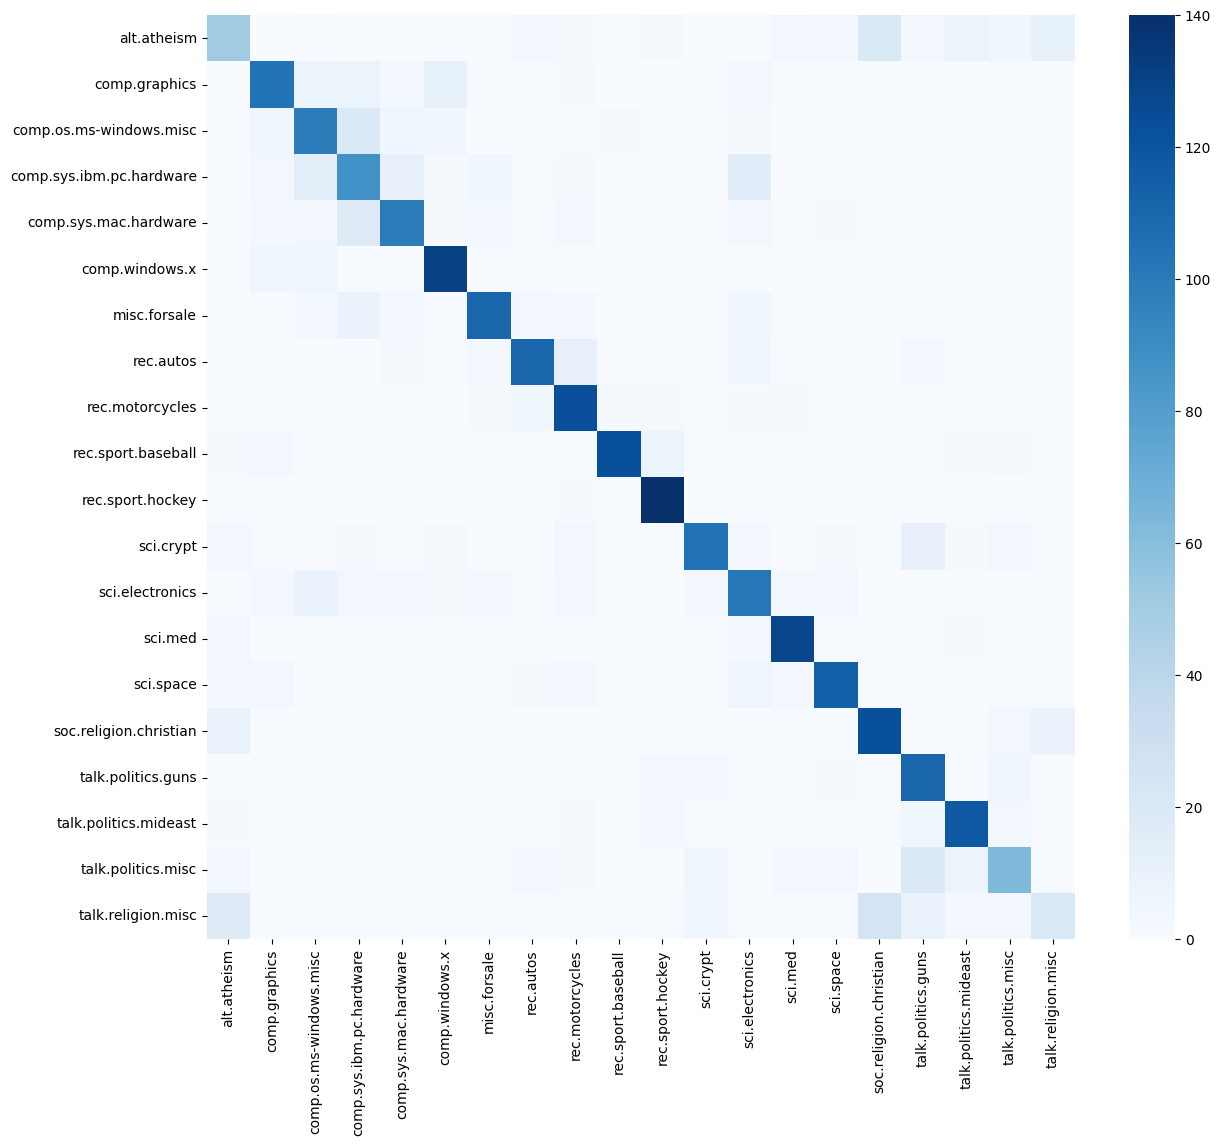

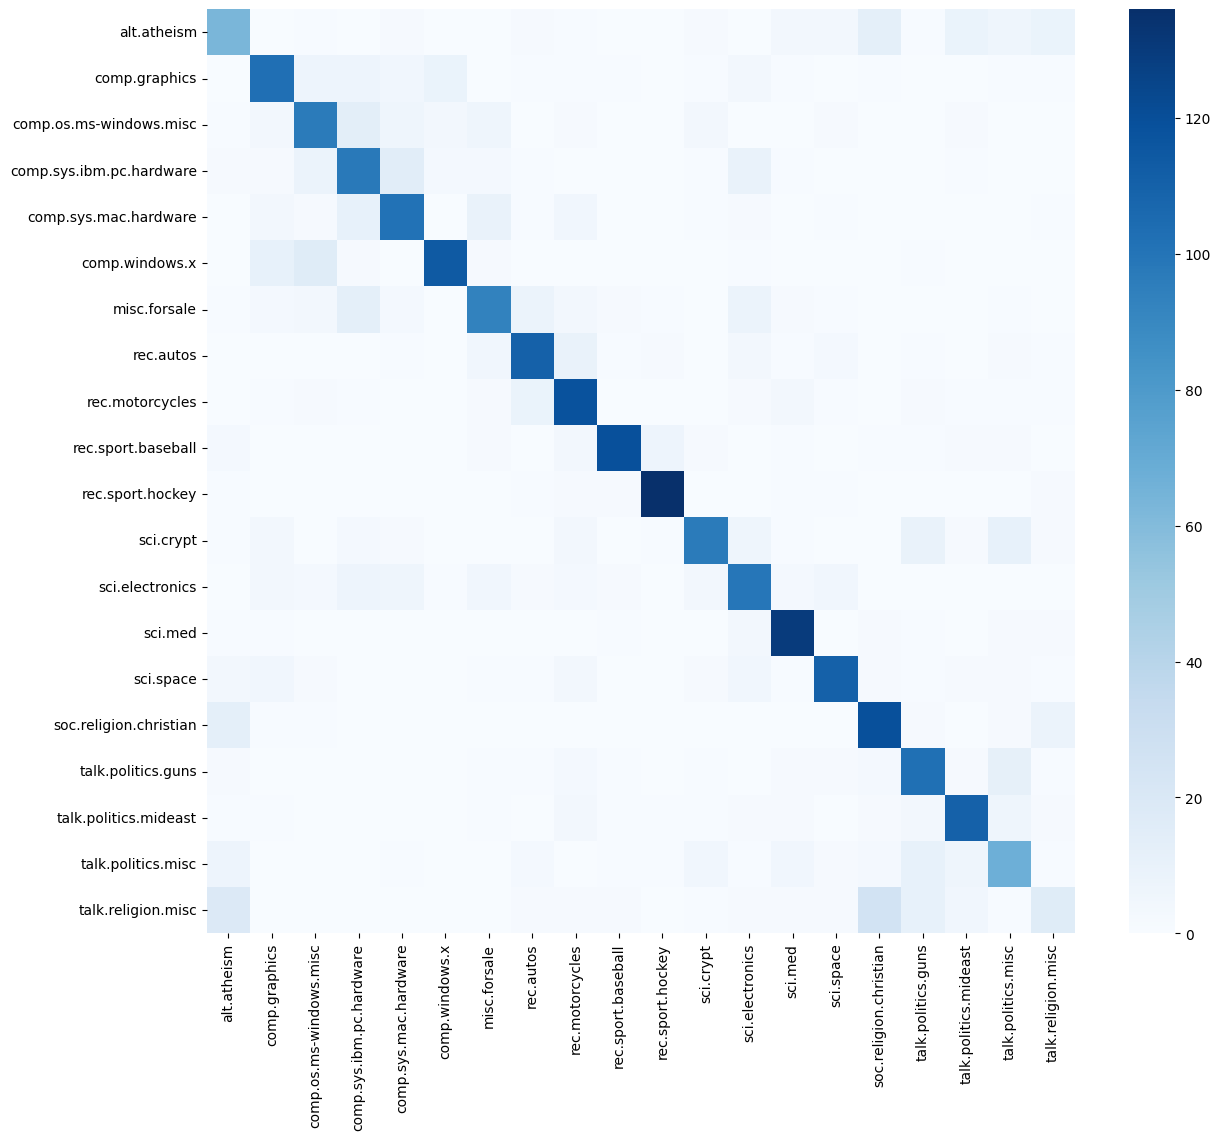

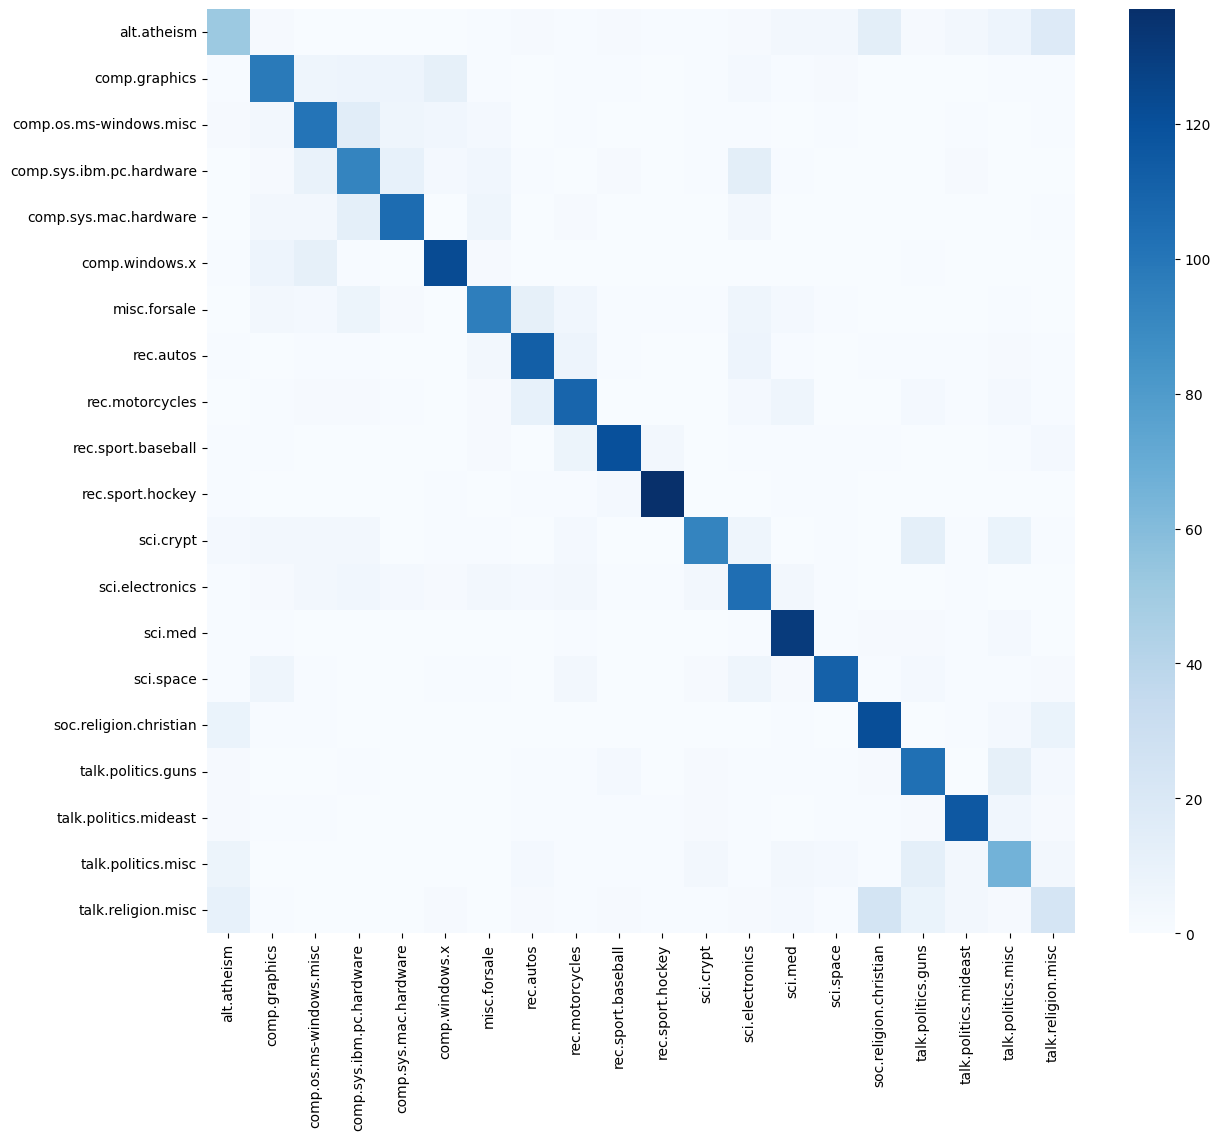

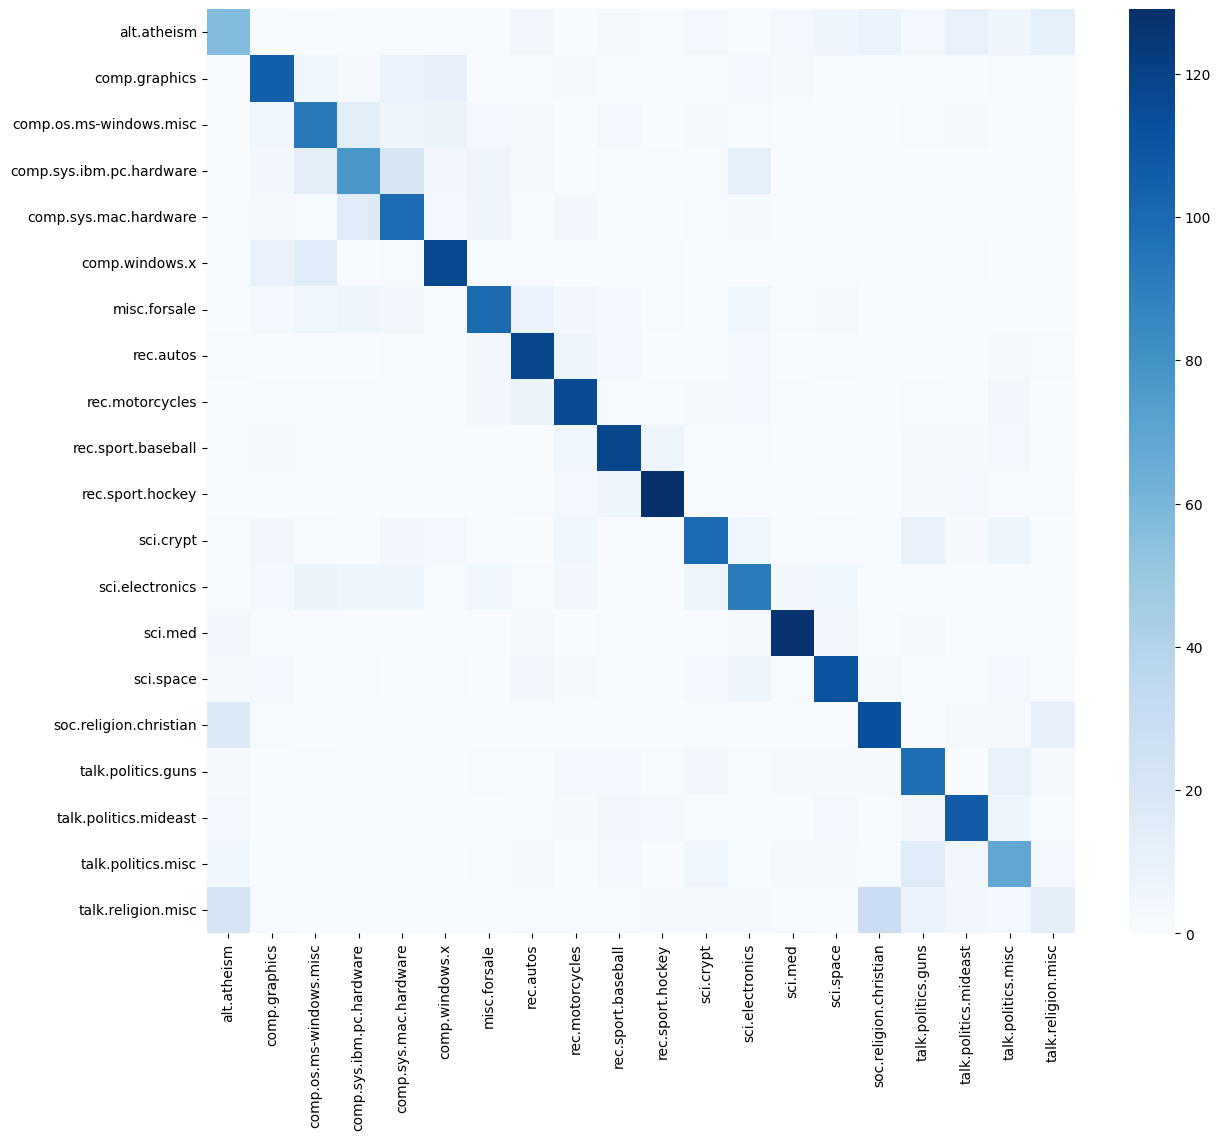

In [23]:
# preprocessing ablation
experiments = [
    ("distilbert-base-uncased", 0.1, "linear"),
]

# baseline
CFG.remove_stopwords = False
CFG.use_stemming = False
CFG.use_augmentation = False

main()

# preprocessing ON
CFG.remove_stopwords = True
CFG.use_stemming = True
CFG.use_augmentation = False

main()

Using device: cuda
Loading dataset...
                                                text  label  \
0  I am sure some bashers of Pens fans are pretty...     10   
1  My brother is in the market for a high-perform...      3   
2  Finally you said what you dream about. Mediter...     17   
3  Think! It's the SCSI card doing the DMA transf...      3   
4  1) I have an old Jasmine drive which I cannot ...      4   

                 label_name  
0          rec.sport.hockey  
1  comp.sys.ibm.pc.hardware  
2     talk.politics.mideast  
3  comp.sys.ibm.pc.hardware  
4     comp.sys.mac.hardware  
Total samples: 18331
Number of classes: 20
Train: 12830 | Val: 2751 | Test: 2750
Train after augmentation: 14754

Running model=distilbert-base-uncased | dropout=0.1 | head=linear


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/2 | Train Loss=1.2542 | Train F1=0.6086 | Val Loss=0.9214 | Val F1=0.7167
Epoch 2/2 | Train Loss=0.5928 | Train F1=0.8146 | Val Loss=0.9851 | Val F1=0.7336

Running model=bert-base-uncased | dropout=0.1 | head=linear


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Attention analysis example:
misc.forsale 0.5627065300941467
      token  attention_from_cls
0     [CLS]            0.119127
36    [SEP]            0.087855
35        .            0.079871
26      dan            0.068398
4      this            0.062872
5   message            0.058677
3   posting            0.046971
8    friend            0.036515
34     1804            0.033322
10     mine            0.031222
LIME not installed. Skipping LIME explanation.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ONNX export skipped due to error: No module named 'onnxscript'

All done.
Artifacts saved to: ./outputs_transformer_project


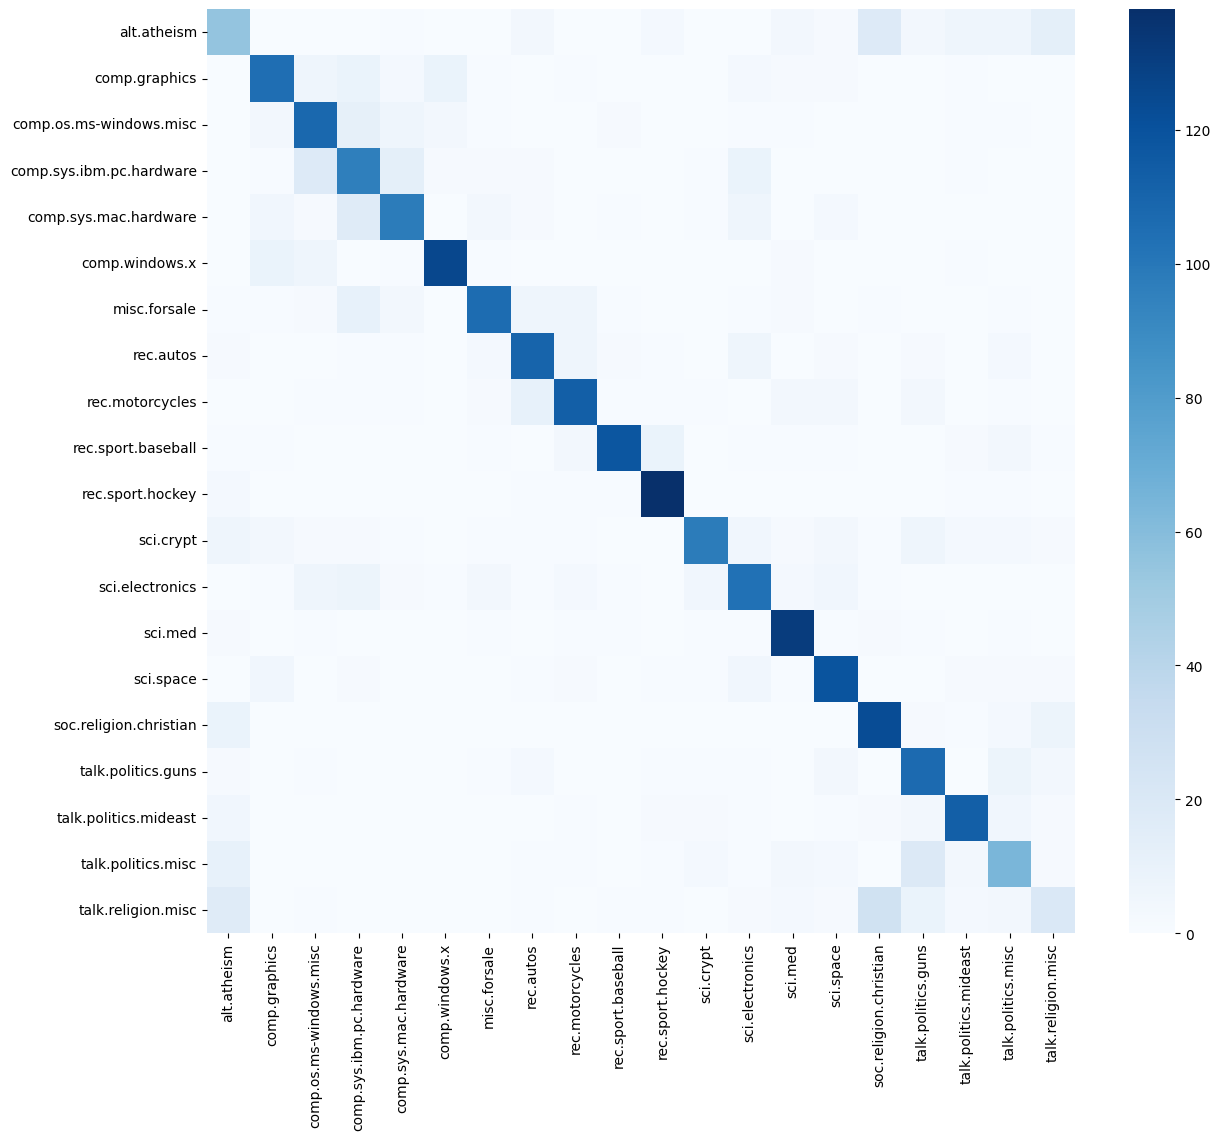

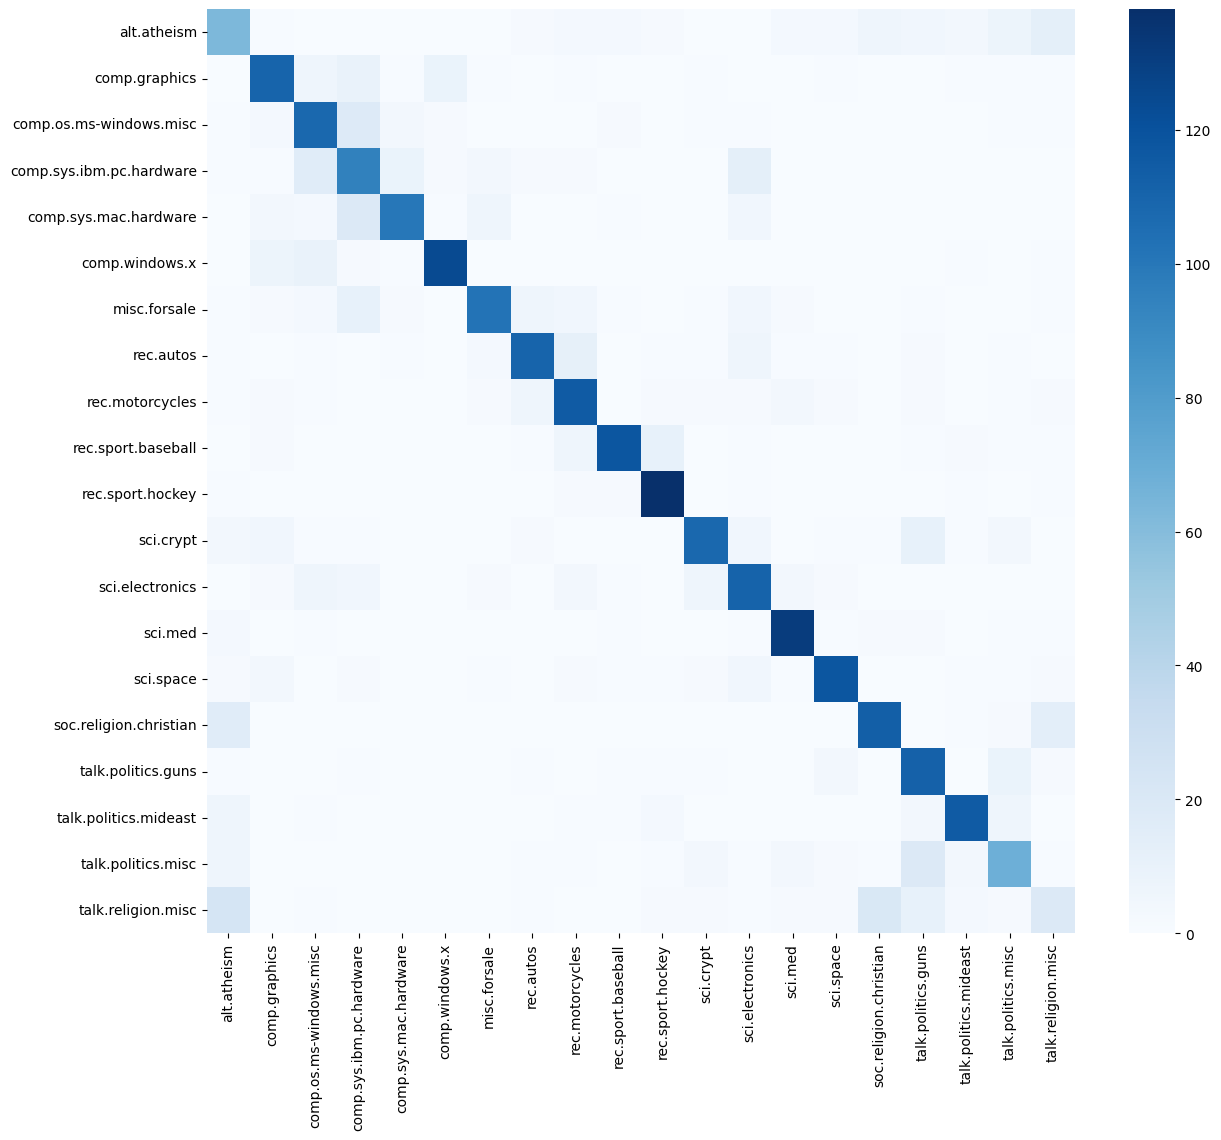

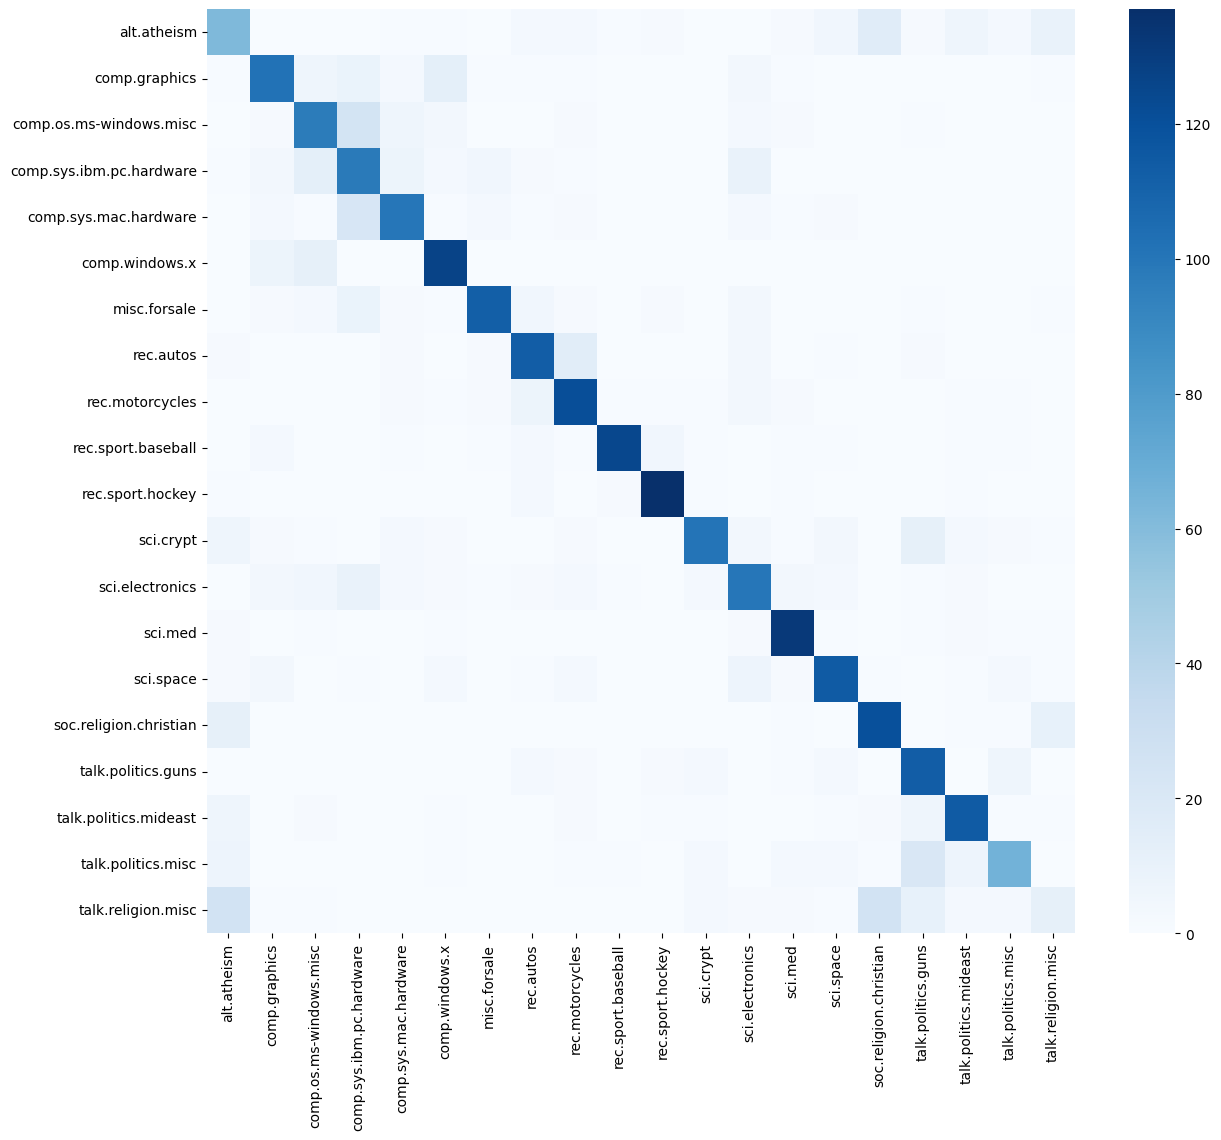

In [24]:
#augmentation ablation
experiments = [
    ("distilbert-base-uncased", 0.1, "linear"),
]

CFG.remove_stopwords = False
CFG.use_stemming = False
CFG.use_augmentation = True

main()